# 4 Pre-Processing Data<a id='4_Pre-Processing_Data'></a>

## 4.1 Contents<a id='4.1_Contents'></a>
* [4 Pre-Processing Data](#4_Pre-Processing_Data)
  * [4.1 Contents](#4.1_Contents)
  * [4.2 Introduction](#4.2_Introduction)
  * [4.3 Imports](#4.3_Imports)
  * [4.4 Load Data](#4.4_Load_Data)
  * [4.5 Train/Test Split](#4.5_Train/Test_Split)
  * [4.6 Scale Dataset](#4.6_Scale_Dataset)
  * [4.7 Save Train Test Datasets](#4.7_Save_Train_Test_Datasets)
  * [4.8 Summary](#4.8_Summary)

## 4.2. Introduction<a id='4.2_Introduction'></a>

In the preceding notebooks, we performed exploratory data analysis and determined the features ('yj_median_income','yj_ev_adoption_lag','yj_ev_charging_density','has_charging_infrastructure','lag_missing_flag','yj_ev_adoption_rate'(target)) for our overall dataset to be used for modeling. 

Key decisions from EDA phase include

1. All remaining core features except 'lag_missing_flag' and 'has_charging_infrastructure' were power-transformed using yeo-johnson method along with target variable ev_adoption_rate to ensure a much more linear relationship.
3. Dropped features: 'income_per_vehicle', 'new_ev_purchase_ratio', 'bev_ratio_within_ev', 'cafv_eligibility_rate', 'ev_charging_stations', 'ev_growth_rate' were all droppped due to weak correlations / anomalous outliers.


In this notebook we will create train/test sets and standardize our data. Next we will save the train/test sets for modeling in the next step.

We will create 2 model ready datasets for the modeling paths described below

1. Linear Regression : Identification & Quantification of EV Adoption Drivers.
2. KMeans Clustering : County Segmentation for Infrastructure Investment Prioritization.

County is not included as a feature for either dataset because for Linear Regression we would like to generalize coefficients across counties instead of memorizing high/low adoption counties. For KMeans, clustering would be based on geography instead of adoption behavior defeating the purpose of segmentation.

However, County and Year fields are kept throughout to interpret model results.

##  4.3 Imports<a id='4.3_Imports'></a>

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import datetime
from library.sb_utils import save_file

## 4.4 Load Data<a id='4.4_Load_Data'></a>

In [2]:
ev_data = pd.read_csv('../data/processed/ev_model_ready_data.csv')
ev_data.head()

,year,county,lag_missing_flag,has_charging_infrastructure,yj_population,yj_median_income,yj_ev_charging_density,yj_ev_adoption_lag,yj_ev_adoption_rate
0,2017,Adams,1,1,-0.735865,-1.560589,-0.771978,-1.393920,-1.475441
1,2018,Adams,0,1,-0.731522,-1.142334,-0.776127,-1.191693,-1.516837
2,2019,Adams,0,1,-0.727110,-1.077710,-0.215099,-1.237306,-1.411533
3,2020,Adams,0,1,-0.718118,-0.810523,-0.228811,-1.121491,-1.320448
4,2021,Adams,0,1,-0.708963,-0.724030,-0.242664,-1.021897,-1.118960


In [3]:
#ensure there is no missing data
ev_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         351 non-null    int64  
 1   county                       351 non-null    object 
 2   lag_missing_flag             351 non-null    int64  
 3   has_charging_infrastructure  351 non-null    int64  
 4   yj_population                351 non-null    float64
 5   yj_median_income             351 non-null    float64
 6   yj_ev_charging_density       351 non-null    float64
 7   yj_ev_adoption_lag           351 non-null    float64
 8   yj_ev_adoption_rate          351 non-null    float64
dtypes: float64(5), int64(3), object(1)
memory usage: 24.8+ KB


In [4]:
ev_data.describe()

,year,lag_missing_flag,has_charging_infrastructure,yj_population,yj_median_income,yj_ev_charging_density,yj_ev_adoption_lag,yj_ev_adoption_rate
count,351.000000,351.000000,351.000000,3.510000e+02,3.510000e+02,3.510000e+02,3.510000e+02,3.510000e+02
mean,2021.000000,0.111111,0.888889,2.732857e-16,-2.142256e-14,-7.591269e-17,3.289550e-17,2.201468e-16
std,2.585675,0.314718,0.314718,1.001428e+00,1.001428e+00,1.001428e+00,1.001428e+00,1.001428e+00
min,2017.000000,0.000000,0.000000,-2.208911e+00,-2.376543e+00,-1.480975e+00,-1.393920e+00,-1.658227e+00
25%,2019.000000,0.000000,1.000000,-6.613061e-01,-6.935767e-01,-8.280738e-01,-8.721776e-01,-8.831921e-01
50%,2021.000000,0.000000,1.000000,4.238461e-02,-5.621594e-02,-1.398671e-01,-1.003853e-01,-4.951703e-02
75%,2023.000000,0.000000,1.000000,7.601171e-01,6.935678e-01,8.115802e-01,8.089799e-01,8.212660e-01
max,2025.000000,1.000000,1.000000,2.309947e+00,2.530486e+00,2.174636e+00,2.096858e+00,2.099076e+00


In [5]:
ev_data.isna().sum()

year                           0
county                         0
lag_missing_flag               0
has_charging_infrastructure    0
yj_population                  0
yj_median_income               0
yj_ev_charging_density         0
yj_ev_adoption_lag             0
yj_ev_adoption_rate            0
dtype: int64

In [6]:
ev_data.duplicated().sum()

np.int64(0)

Now that we have ensured our dataset is model ready without any nulls, duplicates or data format issues, lets go ahead and create the train/test sets.

## 4.5 Train/Test Split<a id='4.5_Train/Test_Split'></a>

Our data is partitioned on county/year and hence we will have to do a time based split for the train and test sets. We are also going to model for 2 feature set/target variable variations as shown below.

In [7]:
#Feature Sets for 2 modeling approaches
target = 'yj_ev_adoption_rate'
lr_features = ['yj_population','yj_median_income','yj_ev_adoption_lag','yj_ev_charging_density', 'has_charging_infrastructure','lag_missing_flag'] #Linear Regression Features
km_features = ['yj_population','yj_median_income','yj_ev_charging_density','has_charging_infrastructure'] #KMeans Features
data = ev_data.copy()
data = data.sort_values(['county','year'])

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         351 non-null    int64  
 1   county                       351 non-null    object 
 2   lag_missing_flag             351 non-null    int64  
 3   has_charging_infrastructure  351 non-null    int64  
 4   yj_population                351 non-null    float64
 5   yj_median_income             351 non-null    float64
 6   yj_ev_charging_density       351 non-null    float64
 7   yj_ev_adoption_lag           351 non-null    float64
 8   yj_ev_adoption_rate          351 non-null    float64
dtypes: float64(5), int64(3), object(1)
memory usage: 24.8+ KB


Please Note : There will be no train/test split for KMeans since clustering is unsupervised. `ev_adoption_rate` will be attached as a label column so we can interpret which clusters correspond to high vs. low adoption after fitting.

In [9]:
#Create train test sets
#Linear Regression Set
train = data[data['year']<=2023].copy()
test = data[data['year']>2023].copy()
X_train_lr = train[lr_features]
y_train_lr = train[target]
X_test_lr = test[lr_features]
y_test_lr = test[target]
#KMeans Set - No train/test split for unsupervised learning set
X_km = data[km_features]
y_km = data[target]

In [10]:
X_train_lr.shape, X_test_lr.shape

((273, 6), (78, 6))

We went for an ~80/20 split for Train/Test data so we could get a decent test size for predictions.

In [11]:
y_train_lr.shape, y_test_lr.shape

((273,), (78,))

In [12]:
X_km.shape

(351, 4)

In [13]:
#Check the 'dtypes' attribute of 'X_train' and 'X_test to verify all features are numeric (Linear Regression)
X_train_lr.dtypes
X_test_lr.dtypes

yj_population                  float64
yj_median_income               float64
yj_ev_adoption_lag             float64
yj_ev_charging_density         float64
has_charging_infrastructure      int64
lag_missing_flag                 int64
dtype: object

In [14]:
#Check the 'dtypes' attribute of 'X_train' and 'X_test to verify all features are numeric (KMeans)
X_km.dtypes

yj_population                  float64
yj_median_income               float64
yj_ev_charging_density         float64
has_charging_infrastructure      int64
dtype: object

## 4.6 Scale Dataset<a id='4.6_Scale_Dataset'></a>

In [15]:
scaler = StandardScaler()
#Linear Regression Scaled Datasets
X_train_lr_scaled=pd.DataFrame(scaler.fit_transform(X_train_lr), columns = lr_features, index=X_train_lr.index)
X_test_lr_scaled=pd.DataFrame(scaler.transform(X_test_lr), columns = lr_features, index=X_test_lr.index)
#KMeans Scaled Dataset
X_km_scaled=pd.DataFrame(scaler.fit_transform(X_km), columns = km_features, index=X_km.index)

Let's run some quick checks for both Linear Regression & KMeans scaled datasets.

In [16]:
#Linear Regression
print("Scaler fit on training data only. Applied to both train and test.")
print(f"\nTraining feature means (should be ~0):")
print(X_train_lr_scaled.mean().round(6))
print(f"\nTraining feature std devs (should be ~1):")
print(X_train_lr_scaled.std().round(6))

Scaler fit on training data only. Applied to both train and test.

Training feature means (should be ~0):
yj_population                 -0.0
yj_median_income              -0.0
yj_ev_adoption_lag             0.0
yj_ev_charging_density        -0.0
has_charging_infrastructure   -0.0
lag_missing_flag               0.0
dtype: float64

Training feature std devs (should be ~1):
yj_population                  1.001837
yj_median_income               1.001837
yj_ev_adoption_lag             1.001837
yj_ev_charging_density         1.001837
has_charging_infrastructure    1.001837
lag_missing_flag               1.001837
dtype: float64


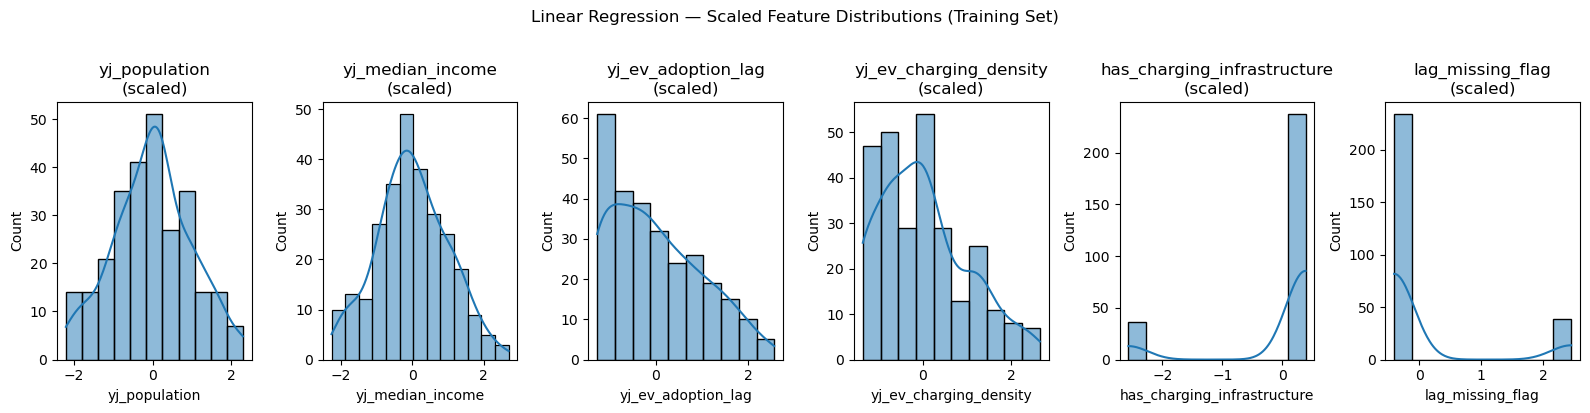

In [17]:
# Visualize scaled distributions — training set
fig, axes = plt.subplots(1, len(lr_features), figsize=(16, 4))
for i, col in enumerate(lr_features):
    sns.histplot(X_train_lr_scaled[col], ax=axes[i], kde=True)
    axes[i].set_title(f'{col}\n(scaled)')
plt.suptitle('Linear Regression — Scaled Feature Distributions (Training Set)', y=1.02)
plt.tight_layout()
plt.show()

In [18]:
#KMeans
print("Scaler fit on full dataset (no train/test split for unsupervised learning).")
print(f"\nFeature means (should be ~0):")
print(X_km_scaled.mean().round(6))
print(f"\nFeature std devs (should be ~1):")
print(X_km_scaled.std().round(6))

Scaler fit on full dataset (no train/test split for unsupervised learning).

Feature means (should be ~0):
yj_population                  0.0
yj_median_income              -0.0
yj_ev_charging_density        -0.0
has_charging_infrastructure    0.0
dtype: float64

Feature std devs (should be ~1):
yj_population                  1.001428
yj_median_income               1.001428
yj_ev_charging_density         1.001428
has_charging_infrastructure    1.001428
dtype: float64


## 4.7 Save best model object from pipeline<a id='4.7_Save_best_model_object_from_pipeline'></a>

Lets save the datasets.
1. Scaled Train and Test sets for Linear Regression.
2. Scaled dataset for KMeans Clustering.

All datasets contain county and year as the reference variables.

In [19]:
#Create train/test datasets to csv files for modeling in next step
datapath = '../data/processed'
#Reference Variables Dataset
ref = data[['county','year']]
#Create Train Test datasets for Linear Regression
lr_train_df = ref.loc[X_train_lr.index].copy().join(X_train_lr_scaled)
lr_train_df[target]=y_train_lr
lr_test_df = ref.loc[X_test_lr.index].copy().join(X_test_lr_scaled)
lr_test_df[target]=y_test_lr
#Create scaled dataset for KMeans
km_df = ref.copy().join(X_km_scaled)
km_df[target]=y_km #Label only

Below are some quick sanity checks prior to saving the datasets.

In [20]:
print(f'lr_train_df rows & Column Count : {lr_train_df.shape}')
print(f'lr_train_df null values count : \n{lr_train_df.isna().sum()}')
print(f'lr_train_df duplicate records count : {lr_train_df.duplicated().sum()}')

lr_train_df rows & Column Count : (273, 9)
lr_train_df null values count : 
county                         0
year                           0
yj_population                  0
yj_median_income               0
yj_ev_adoption_lag             0
yj_ev_charging_density         0
has_charging_infrastructure    0
lag_missing_flag               0
yj_ev_adoption_rate            0
dtype: int64
lr_train_df duplicate records count : 0


In [21]:
print(f'lr_test_df rows & Column Count : {lr_test_df.shape}')
print(f'lr_test_df null values count : \n{lr_test_df.isna().sum()}')
print(f'lr_test_df duplicate records count : {lr_test_df.duplicated().sum()}')

lr_test_df rows & Column Count : (78, 9)
lr_test_df null values count : 
county                         0
year                           0
yj_population                  0
yj_median_income               0
yj_ev_adoption_lag             0
yj_ev_charging_density         0
has_charging_infrastructure    0
lag_missing_flag               0
yj_ev_adoption_rate            0
dtype: int64
lr_test_df duplicate records count : 0


In [22]:
print(f'km_df rows & Column Count : {km_df.shape}')
print(f'km_df null values count : \n{km_df.isna().sum()}')
print(f'km_df duplicate records count : {km_df.duplicated().sum()}')

km_df rows & Column Count : (351, 7)
km_df null values count : 
county                         0
year                           0
yj_population                  0
yj_median_income               0
yj_ev_charging_density         0
has_charging_infrastructure    0
yj_ev_adoption_rate            0
dtype: int64
km_df duplicate records count : 0


In [23]:
save_file(lr_train_df, 'ev_lr_train_scaled.csv', datapath)
save_file(lr_test_df, 'ev_lr_test_scaled.csv', datapath)
save_file(km_df, 'ev_km_scaled.csv', datapath)

A file already exists with this name.



Do you want to overwrite? (Y/N) Y


Writing file.  "../data/processed\ev_lr_train_scaled.csv"
A file already exists with this name.



Do you want to overwrite? (Y/N) Y


Writing file.  "../data/processed\ev_lr_test_scaled.csv"
A file already exists with this name.



Do you want to overwrite? (Y/N) Y


Writing file.  "../data/processed\ev_km_scaled.csv"


## 4.8 Summary<a id='4.8_Summary'></a>

1. We started by loading the model ready dataset with log features created during Exploratory Data Analysis step. 

2. We checked for missing values for all features and target variable and made sure the dataset looked complete.

3. Train/Test sets were created for 2 different modeling strategies to capture different perspectives.

* For the first Linear Regression train/test split, yj_ev_adoption_rate was our target and primary features were yj_population, yj_median_income, yj_ev_charging_density, yj_ev_adoption_lag, has_charging_infrastructure & lag_missing_flag.

* For the second KMeans unsupervised learning dataset, no train/test split was needed. yj_ev_adoption_rate was our target and yj_population ,yj_median_income, yj_ev_charging_density, has_charging_infrastructure were our primary features.

4. Train/Test split was done in a time-aware manner since our dataset is a time series (county/year level data from 2017-2025).

5. Numerical Features were standardized to ensure model readiness.

6. Finally, Linear Regression train, test datasets and KMeans dataset with county & year as reference variables were saved for modeling in our next step.